In [1]:
pwd()

'/home/user/Documents/repos/pyptv/pyptv'

In [2]:
import optv
import pathlib
import os

In [3]:
# PyPTV works only inside the working folder
working_folder = pathlib.Path('../tests/test_cavity/')
os.chdir(working_folder)


working_folder = pathlib.Path('.')
par_path = working_folder / "parameters"

In [4]:
with open(par_path / "ptv.par", "r", encoding="utf8") as f:
    n_cams = int(f.readline())
    
print(f'{n_cams} cameras setup')

4 cameras setup


In [5]:
from ptv import *

In [6]:
# Read all the parameters in respective structures
cpar, spar, vpar, track_par, tpar, cals, epar = py_start_proc_c(n_cams)

In [7]:
cpar.get_allCam_flag()

False

In [8]:
# this is the default targ_rec.par for images
tpar.get_grey_thresholds()

array([ 9,  9,  9, 11], dtype=int32)

In [9]:
# we need for calibration:
tpar.read(b"parameters/detect_plate.par")
tpar.get_grey_thresholds()

array([40, 40, 40, 40], dtype=int32)

In [10]:
import parameters as par
from skimage.util import img_as_ubyte

In [11]:
calParams = par.CalOriParams(n_cams, par_path)
calParams.read()

In [12]:
if epar.Combine_Flag is True:
    print("Combine Flag")
    MultiParams = par.MultiPlaneParams()
    MultiParams.read()
    for i in range(MultiParams.n_planes):
        print(MultiParams.plane_name[i])

    pass_raw_orient = True
    status_text = "Multiplane calibration."

In [13]:
# read calibration images
cal_images = []
for i in range(n_cams):
    imname = calParams.img_cal_name[i]
    # for imname in calParams.img_cal_name:
    # cal_images.append(imread(imname))
    im = imread(imname)
    if im.ndim > 2:
        im = rgb2gray(im)

    cal_images.append(img_as_ubyte(im))

In [14]:
from dataclasses import dataclass

@dataclass
class CameraClass:
    man_ori: np.array((4,))
        
camera = 4*[CameraClass(np.zeros((4,)))]

In [15]:
# Loading manual parameters here
man_ori_path =  par_path / "man_ori.par"

with open(man_ori_path, "r", encoding='utf8') as f:
    for i in range(n_cams):
        camera.append([])
        for j in range(4):
            camera[i].man_ori[j] = int(f.readline().strip())
            
status_text = "Initialization finished."

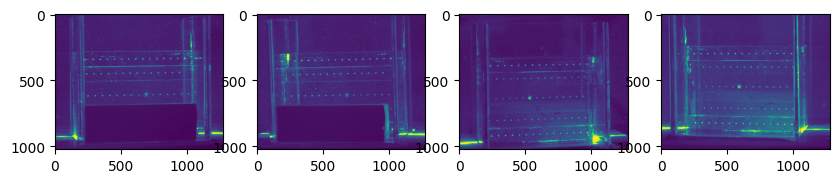

In [16]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,4, figsize=(10,10))
                       
for i,c in enumerate(cal_images):
    ax[i].imshow(c)
    # ax[i].plot(camera[i].man_ori[j])

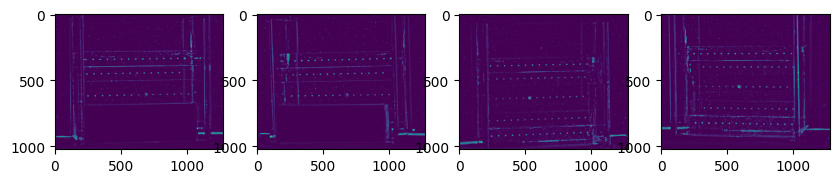

In [17]:
# highpass
high_passed = py_pre_processing_c(cal_images, cpar)

fig, ax = plt.subplots(1,4, figsize=(10,10))
                       
for i,c in enumerate(high_passed):
    ax[i].imshow(c)
    # ax[i].plot(camera[i].man_ori[j])

In [18]:
detections, corrected = py_detection_proc_c(
    high_passed, cpar, tpar, cals)

Inside segmentation.pyx 

Calling liboptv 

Freeing targs and ret 

Free memory, filling t with 92 targets 

Returning t 

Inside segmentation.pyx 

Calling liboptv 

Freeing targs and ret 

Free memory, filling t with 80 targets 

Returning t 

Inside segmentation.pyx 

Calling liboptv 

Freeing targs and ret 

Free memory, filling t with 116 targets 

Returning t 

Inside segmentation.pyx 

Calling liboptv 

Freeing targs and ret 

Free memory, filling t with 150 targets 

Returning t 

[<optv.tracking_framebuf.TargetArray object at 0x7f315fbc5570>, <optv.tracking_framebuf.TargetArray object at 0x7f315fbc5090>, <optv.tracking_framebuf.TargetArray object at 0x7f315fbc57e0>, <optv.tracking_framebuf.TargetArray object at 0x7f315f8d11b0>]


In [26]:
x = [[i.pos()[0] for i in row] for row in detections]
y = [[i.pos()[1] for i in row] for row in detections]

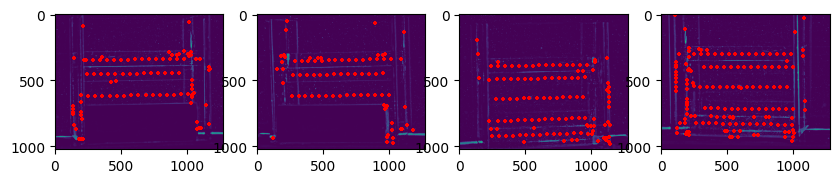

In [36]:
fig, ax = plt.subplots(1,n_cams,figsize=(10,10))
for i,c in enumerate(high_passed):
    ax[i].imshow(c)
    ax[i].scatter(x[i], y[i], 5, marker='+',color='r')

In [37]:
# later use for manual clicks
# https://matplotlib.org/stable/gallery/event_handling/cursor_demo.html
# skip this for now

In [43]:
def _read_cal_points():
    return np.atleast_1d(
        np.loadtxt(
            pathlib.Path(calParams.fixp_name),
            dtype=[("id", "i4"), ("pos", "3f8")],
            skiprows=0,
        ))

In [44]:
cal_points = _read_cal_points()

In [54]:
cal_points['pos']

array([[-40., -25.,   8.],
       [-40., -15.,   0.],
       [-40.,   0.,  -8.],
       [-40.,  15.,   0.],
       [-40.,  25.,   8.],
       [-35., -25.,   8.],
       [-35., -15.,   0.],
       [-35.,   0.,  -8.],
       [-35.,  15.,   0.],
       [-35.,  25.,   8.],
       [-30., -25.,   8.],
       [-30., -15.,   0.],
       [-30.,   0.,  -8.],
       [-30.,  15.,   0.],
       [-30.,  25.,   8.],
       [-25., -25.,   8.],
       [-25., -15.,   0.],
       [-25.,   0.,  -8.],
       [-25.,  15.,   0.],
       [-25.,  25.,   8.],
       [-20., -25.,   8.],
       [-20., -15.,   0.],
       [-20.,   0.,  -8.],
       [-20.,  15.,   0.],
       [-20.,  25.,   8.],
       [-15., -25.,   8.],
       [-15., -15.,   0.],
       [-15.,   0.,  -8.],
       [-15.,  15.,   0.],
       [-15.,  25.,   8.],
       [-10., -25.,   8.],
       [-10., -15.,   0.],
       [-10.,   0.,  -8.],
       [-10.,  15.,   0.],
       [-10.,  25.,   8.],
       [ -5., -25.,   8.],
       [ -5., -15.,   0.],
 

In [45]:
from optv.imgcoord import image_coordinates  # type: ignore
from optv.transforms import convert_arr_metric_to_pixel  # type: ignore
from optv.orientation import match_detection_to_ref  # type: ignore
from optv.orientation import external_calibration, full_calibration  # type: ignore
from optv.calibration import Calibration  # type: ignore
from optv.tracking_framebuf import TargetArray  # type: ignore

In [51]:
def drawcross(xlabel, ylabel, x, y, color, size, i_cam):
    ax[i_cam].scatter(x[i], y[i], 5, marker='+',color=color)

In [56]:
def _project_cal_points(i_cam, color="red"):
    x, y = [], []
    for row in cal_points:
        projected = image_coordinates(
            np.atleast_2d(row["pos"]),
            cals[i_cam],
            cpar.get_multimedia_params(),
        )
        pos = convert_arr_metric_to_pixel(projected, cpar)

        x.append(pos[0][0])
        y.append(pos[0][1])
        
    return x,y

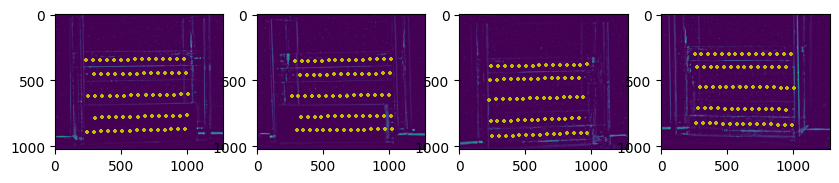

In [58]:
fig, ax = plt.subplots(1,n_cams,figsize=(10,10))
for i,c in enumerate(high_passed):
    ax[i].imshow(c)
    x,y = _project_cal_points(i)
    ax[i].scatter(x, y, 5, marker='+',color='y')

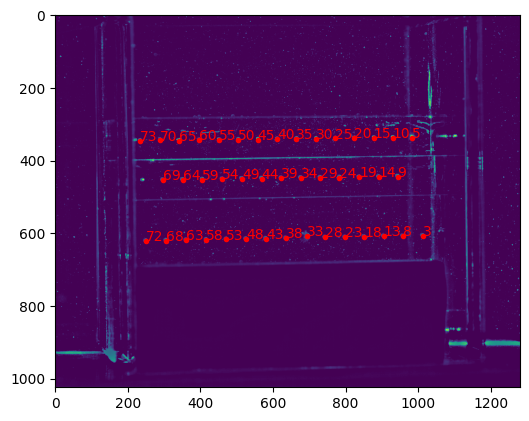

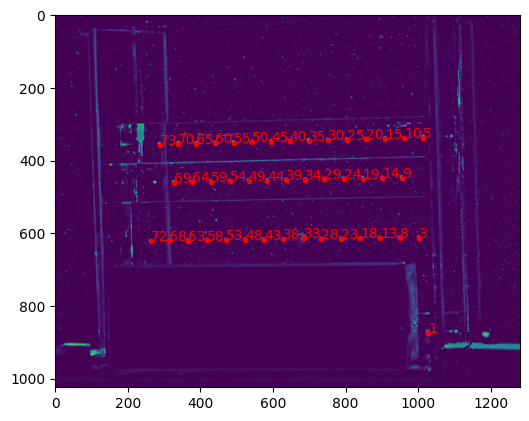

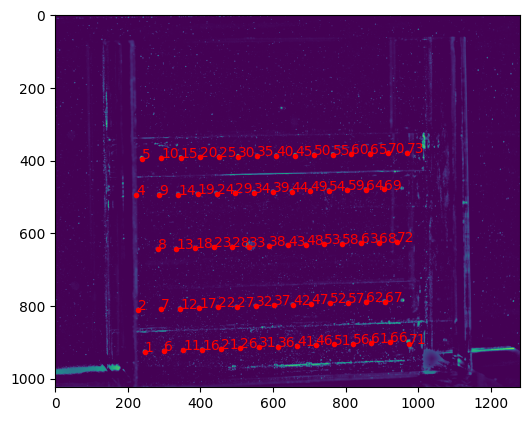

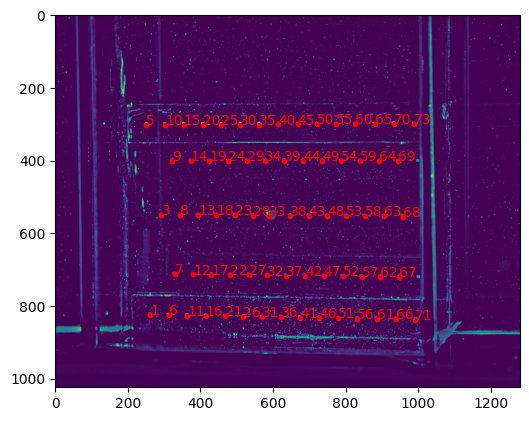

In [73]:
# sortgrid
"""
Uses sortgrid function of liboptv to match between the
calibration points in the fixp target file and the targets
detected in the images
"""
sorted_targs = []
for i_cam in range(n_cams):
    fig, ax = plt.subplots(figsize=(6,6))

    targs = match_detection_to_ref(
        cals[i_cam],
        cal_points["pos"],
        detections[i_cam],
        cpar,
    )
    x, y, pnr = [], [], []
    for t in targs:
        if t.pnr() != -999:
            pnr.append(cal_points["id"][t.pnr()])
            x.append(t.pos()[0])
            y.append(t.pos()[1])

    ax.imshow(high_passed[i_cam])
    ax.scatter(x,y,marker='.', color='r')
    for xx,yy,ss in zip(x,y,pnr):
        ax.text(xx,yy,ss,color='r')
    # ax.text(x,y,pnr)
    
    sorted_targs.append(targs)

In [ ]:
from optv.calibration import Calibration

In [ ]:
cal = Calibration()

In [ ]:
cal.get_pos()

In [ ]:
cal.get_angles()

In [ ]:
cal.get_primary_point()

In [ ]:
cal.get_radial_distortion()

In [ ]:
cal.get_decentering()

In [ ]:
import numpy as np
inters = cal.get_pos() # including R
angs = cal.get_angles()
primary_point = cal.get_primary_point()
rad_dist = cal.get_radial_distortion()
decent = cal.get_decentering()
# R = inters[2] 
# inters = inters[:2]


solution = np.r_[inters, angs, primary_point, rad_dist, decent]

In [ ]:
solution.shape

In [ ]:
def fitness(solution):
    